# Predictive Analytics: Two-stage NN Grid Search

Based on the findings in the nn_baseline notebook we perform a grid search in this notebook. As census_tract_1h looked most promising in the baseline nn notebook we decided to only use this dataset for the grid search. Thereby reducing computation cost. Further a central finding is that the model learns to predict 0 demand very easy while struggling to predict high demand. Therefore this is one focus within this grid search.

To further reduce the computational effor we decided to split the grid search into two stages:

- **Stage 1:** screen seven zero-handling strategies with the baseline architecture and a maximum of 20 epochs
- **Stage 2:** combine the best two strategies with two architectures and two learning rates, using a maximum of 30 epochs

Further we use a balanced MAE variant instead of just using simple MAE for the checkpoint selection. Thereby we try to acknowledge that zero demand is easy to predict but "real demand" is what we are really interested in:

Balanced MAE = a * zero-MAE + (1-a) * non-zero-MAE, where we set a to be 0,5.

In [1]:
from dataclasses import dataclass
from itertools import product
import math
import random

import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from sklearn.preprocessing import StandardScaler
import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from helper_functions import (
    collect_predictions,
    compute_regression_metrics,
    get_torch_device,
    load_model_from_checkpoint,
    plot_regression_diagnostics,
)
from run_config import MODELS_DIR, PATHS, RUN_MODE, demand_split_paths

## Configuration

As mentioned we only train on census_tract_1h

In [ ]:
if RUN_MODE != "full":
    print("This grid-search notebook is intentionally build for RUN_MODE='full'")

DATASET_CONFIGS = (
    {"spatial_unit": "census_tracts", "spatial_col": "census_tract", "time_unit": "1h"},
)

TARGET_COL = "trip_count"
TIME_COL = "datetime_hour"
MODEL_VERSION = "grid_search_v1"
OUTPUT_DIR = MODELS_DIR / "nn_grid_search"
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)
BASELINE_PREDICTION_DIR = PATHS.train_test_dir / "baseline_predictions"

EXCLUDE_COLS = {
    TARGET_COL, TIME_COL, "date", "_split_bucket",
    "month", "weekday", "hour",
    "weather_qc_corrected", "station_observed", "weather_imputed", "precipitation_missing",
    "trip_seconds_sum", "trip_seconds_mean", "trip_seconds_min", "trip_seconds_max",
    "trip_miles_sum", "trip_miles_mean", "trip_miles_min", "trip_miles_max",
    "fare_sum", "fare_mean", "fare_min", "fare_max",
    "tips_sum", "tips_mean", "tips_min", "tips_max",
    "tolls_sum", "tolls_mean", "tolls_min", "tolls_max",
    "extras_sum", "extras_mean", "extras_min", "extras_max",
    "trip_total_sum", "trip_total_mean", "trip_total_min", "trip_total_max",
    "most_common_payment_type",
}

BASELINE_PREDICTION_COLS = {
    "zero": "prediction_zero",
    "global_median": "prediction_global_median",
    "spatial_time_weekday_mean": "prediction_spatial_time_weekday_mean",
}
SKILL_SCORE_REFERENCE = "spatial_time_weekday_mean"

BASE_SEED = 42
BATCH_SIZE = 1024
DEMAND_THRESHOLD = 0.5
BALANCED_MAE_ALPHA = 0.5
MIN_DELTA = 0.0

# Stage 1
STAGE_1_EPOCHS = 20
STAGE_1_PATIENCE = 4
STAGE_1_HIDDEN_DIMS = (64, 32)
STAGE_1_LEARNING_RATE = 0.001
STAGE_1_STRATEGIES = (
    {"strategy": "standard"},
    {"strategy": "weighted_loss", "positive_weight": 2.0},
    {"strategy": "weighted_loss", "positive_weight": 5.0},
    {"strategy": "weighted_loss", "positive_weight": 10.0},
    {"strategy": "zero_undersampling", "zero_to_positive_ratio": 1.0},
    {"strategy": "zero_undersampling", "zero_to_positive_ratio": 2.0},
    {"strategy": "zero_undersampling", "zero_to_positive_ratio": 5.0},
)

# Stage 2 
# 2 selected strategies × 2 architectures × 2 learning rates = at most 8 runs per dataset
TOP_STRATEGIES_FOR_STAGE_2 = 2
STAGE_2_EPOCHS = 30
STAGE_2_PATIENCE = 6
STAGE_2_HIDDEN_DIMS = ((64, 32), (128, 64))
STAGE_2_LEARNING_RATES = (0.001, 0.0003)


def split_paths_for(config):
    kwargs = {}
    if config["spatial_unit"] == "hexagon":
        kwargs["h3_resolution"] = config["h3_resolution"]
    return demand_split_paths(config["spatial_unit"], config["time_unit"], **kwargs)


def model_tag_for(config):
    if config["spatial_unit"] == "hexagon":
        return f"hexagon_h3r{config['h3_resolution']}_{config['time_unit']}"
    return f"{config['spatial_unit']}_{config['time_unit']}"

## Configurable baseline architecture

The hidden layer is varied in the grid search. Spatial embedding, ReLu and Softplus remain unchanged.

In [3]:
class TaxiDemandGridNN(nn.Module):
    def __init__(self, input_dim, num_spatial_units, hidden_dims):
        super().__init__()
        layers = []
        previous_dim = input_dim
        for hidden_dim in hidden_dims:
            layers.extend((nn.Linear(previous_dim, hidden_dim), nn.ReLU()))
            previous_dim = hidden_dim
        layers.append(nn.Linear(previous_dim, 1))
        self.network = nn.Sequential(*layers)
        self.spatial_bias = nn.Embedding(
            num_embeddings=num_spatial_units + 1,
            embedding_dim=1,
            padding_idx=0,
        )
        nn.init.zeros_(self.spatial_bias.weight)
        self.output_activation = nn.Softplus()

    def forward(self, x, spatial_idx):
        return self.output_activation(self.network(x) + self.spatial_bias(spatial_idx))

## Load and prepare each dataset once

In [4]:
@dataclass
class PreparedDataset:
    config: dict
    model_tag: str
    spatial_col: str
    feature_cols: list[str]
    spatial_to_idx: dict[str, int]
    scaler: StandardScaler
    train_X: torch.Tensor
    train_spatial: torch.Tensor
    train_y: torch.Tensor
    val_loader: DataLoader
    val_df: pl.DataFrame


def set_reproducible_seed(seed):
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)
    torch.use_deterministic_algorithms(True, warn_only=True)


def validate_model_frame(frame, feature_cols, spatial_col, split_name):
    required = {*feature_cols, spatial_col, TARGET_COL, "weekday", "hour"}
    missing = required.difference(frame.columns)
    if missing:
        raise ValueError(f"{split_name} is missing columns: {sorted(missing)}")
    if frame.is_empty():
        raise ValueError(f"{split_name} split is empty")
    selected = frame.select([*feature_cols, TARGET_COL])
    null_counts = selected.null_count().row(0, named=True)
    columns_with_nulls = [name for name, count in null_counts.items() if count]
    if columns_with_nulls:
        raise ValueError(f"{split_name} contains nulls in: {columns_with_nulls}")
    values = selected.to_numpy()
    if not np.issubdtype(values.dtype, np.number):
        raise TypeError(f"{split_name} model features and target must be numeric")
    if not np.isfinite(values).all():
        raise ValueError(f"{split_name} contains non-finite model values")


def encode_spatial(frame, spatial_col, spatial_to_idx):
    return (
        frame.select(
            pl.col(spatial_col).cast(pl.String)
            .replace_strict(spatial_to_idx, default=0)
            .cast(pl.Int64).alias("spatial_idx")
        ).to_series().to_numpy()
    )


def prepare_dataset(config):
    paths = split_paths_for(config)
    train_df = pl.read_parquet(paths["train"])
    val_df = pl.read_parquet(paths["val"])
    spatial_col = config["spatial_col"]
    feature_cols = [
        col for col in train_df.columns
        if col not in EXCLUDE_COLS and col != spatial_col
    ]
    validate_model_frame(train_df, feature_cols, spatial_col, "train")
    validate_model_frame(val_df, feature_cols, spatial_col, "validation")
    if train_df.select(feature_cols).schema != val_df.select(feature_cols).schema:
        raise TypeError("Train and validation feature schemas differ")

    spatial_values = sorted(
        train_df.select(pl.col(spatial_col).cast(pl.String)).to_series().unique().to_list()
    )
    spatial_to_idx = {value: index + 1 for index, value in enumerate(spatial_values)}
    scaler = StandardScaler().fit(train_df.select(feature_cols).to_numpy())

    train_X = torch.tensor(
        scaler.transform(train_df.select(feature_cols).to_numpy()).astype("float32")
    )
    train_spatial = torch.tensor(
        encode_spatial(train_df, spatial_col, spatial_to_idx), dtype=torch.long
    )
    train_y = torch.tensor(
        train_df.select(TARGET_COL).to_numpy().astype("float32")
    )
    val_X = torch.tensor(
        scaler.transform(val_df.select(feature_cols).to_numpy()).astype("float32")
    )
    val_spatial = torch.tensor(
        encode_spatial(val_df, spatial_col, spatial_to_idx), dtype=torch.long
    )
    val_y = torch.tensor(val_df.select(TARGET_COL).to_numpy().astype("float32"))
    val_loader = DataLoader(
        TensorDataset(val_X, val_spatial, val_y), batch_size=BATCH_SIZE, shuffle=False
    )

    print(
        f"Prepared {model_tag_for(config)}: train={train_df.height:,}, val={val_df.height:,}, "
        f"train zero share={(train_y == 0).float().mean().item():.3f}"
    )
    return PreparedDataset(
        config=dict(config), model_tag=model_tag_for(config), spatial_col=spatial_col,
        feature_cols=feature_cols, spatial_to_idx=spatial_to_idx, scaler=scaler,
        train_X=train_X, train_spatial=train_spatial, train_y=train_y,
        val_loader=val_loader, val_df=val_df,
    )

## Zero-handling strategies

In [5]:
def strategy_tag(strategy_config):
    strategy = strategy_config["strategy"]
    if strategy == "weighted_loss":
        return f"weighted_pw{strategy_config['positive_weight']:g}".replace(".", "p")
    if strategy == "zero_undersampling":
        return f"undersample_zp{strategy_config['zero_to_positive_ratio']:g}".replace(".", "p")
    return "standard"


def make_train_loader(prepared, strategy_config, seed):
    strategy = strategy_config["strategy"]
    if strategy == "zero_undersampling":
        y_flat = prepared.train_y.reshape(-1)
        positive_indices = torch.where(y_flat > 0)[0]
        zero_indices = torch.where(y_flat == 0)[0]
        requested_zeros = int(
            strategy_config["zero_to_positive_ratio"] * positive_indices.numel()
        )
        sampled_zero_count = min(requested_zeros, zero_indices.numel())
        generator = torch.Generator().manual_seed(seed)
        sampled_zeros = zero_indices[
            torch.randperm(zero_indices.numel(), generator=generator)[:sampled_zero_count]
        ]
        indices = torch.cat((positive_indices, sampled_zeros))
        X = prepared.train_X[indices]
        spatial = prepared.train_spatial[indices]
        y = prepared.train_y[indices]
    else:
        X, spatial, y = prepared.train_X, prepared.train_spatial, prepared.train_y

    shuffle_generator = torch.Generator().manual_seed(seed)
    loader = DataLoader(
        TensorDataset(X, spatial, y), batch_size=BATCH_SIZE, shuffle=True,
        generator=shuffle_generator,
    )
    return loader, len(y)


def compute_training_loss(y_pred, y_true, strategy_config):
    squared_error = (y_pred - y_true) ** 2
    if strategy_config["strategy"] == "weighted_loss":
        positive_weight = strategy_config["positive_weight"]
        weights = torch.where(y_true > 0, positive_weight, 1.0)
        return (weights * squared_error).sum() / weights.sum()
    return squared_error.mean()


def train_one_epoch(model, train_loader, optimizer, strategy_config, device):
    model.train()
    total_weighted_loss = 0.0
    total_samples = 0
    for X_batch, spatial_batch, y_batch in train_loader:
        X_batch, spatial_batch, y_batch = X_batch.to(device), spatial_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = compute_training_loss(model(X_batch, spatial_batch), y_batch, strategy_config)
        loss.backward()
        optimizer.step()
        total_weighted_loss += loss.item() * X_batch.size(0)
        total_samples += X_batch.size(0)
    return total_weighted_loss / total_samples


def evaluate_epoch(model, val_loader, device):
    model.eval()
    absolute_error = squared_error = 0.0
    zero_absolute_error = nonzero_absolute_error = 0.0
    total_samples = zero_samples = nonzero_samples = 0
    with torch.inference_mode():
        for X_batch, spatial_batch, y_batch in val_loader:
            X_batch, spatial_batch, y_batch = X_batch.to(device), spatial_batch.to(device), y_batch.to(device)
            y_pred = model(X_batch, spatial_batch)
            batch_absolute_error = torch.abs(y_pred - y_batch)
            zero_mask = y_batch <= 0
            nonzero_mask = ~zero_mask
            absolute_error += batch_absolute_error.sum().item()
            squared_error += ((y_pred - y_batch) ** 2).sum().item()
            zero_absolute_error += batch_absolute_error[zero_mask].sum().item()
            nonzero_absolute_error += batch_absolute_error[nonzero_mask].sum().item()
            total_samples += X_batch.size(0)
            zero_samples += zero_mask.sum().item()
            nonzero_samples += nonzero_mask.sum().item()
    if zero_samples == 0 or nonzero_samples == 0:
        raise ValueError("Balanced MAE requires zero and non-zero validation targets")
    val_zero_mae = zero_absolute_error / zero_samples
    val_nonzero_mae = nonzero_absolute_error / nonzero_samples
    val_balanced_mae = (
        (1.0 - BALANCED_MAE_ALPHA) * val_zero_mae
        + BALANCED_MAE_ALPHA * val_nonzero_mae
    )
    return {
        "val_mae": absolute_error / total_samples,
        "val_mse": squared_error / total_samples,
        "val_rmse": math.sqrt(squared_error / total_samples),
        "val_zero_mae": val_zero_mae,
        "val_nonzero_mae": val_nonzero_mae,
        "val_balanced_mae": val_balanced_mae,
    }

## Reuse and validate the external validation baselines

The grid search loads the `*_val_baselines.parquet` file like the NN baseline. Keys and targets are checked before metrics or the MAE Skill Score are calculated

In [6]:
def load_validation_baseline_metrics(prepared):
    path = BASELINE_PREDICTION_DIR / f"{prepared.model_tag}_val_baselines.parquet"
    if not path.exists():
        raise FileNotFoundError(
            f"Validation baseline file not found: {path}. "
            "Run 03_01_predictive_analytics_baseline.ipynb first."
        )
    predictions = pl.read_parquet(path)
    required = {
        TIME_COL, prepared.spatial_col, "y_true", *BASELINE_PREDICTION_COLS.values()
    }
    missing = required.difference(predictions.columns)
    if missing:
        raise ValueError(f"Baseline file is missing columns: {sorted(missing)}")
    if predictions.height != prepared.val_df.height:
        raise ValueError("Baseline and validation row counts differ")
    key_cols = [TIME_COL, prepared.spatial_col]
    if predictions.select(key_cols).unique().height != predictions.height:
        raise ValueError(f"Baseline file contains duplicate keys: {path}")
    expected = prepared.val_df.select(
        *key_cols, pl.col(TARGET_COL).cast(pl.Float64).alias("expected_y_true")
    )
    aligned = expected.join(
        predictions.select(*key_cols, "y_true"), on=key_cols, how="left"
    )
    if aligned["y_true"].null_count():
        raise ValueError("Baseline file does not contain every validation key")
    max_difference = aligned.select(
        (pl.col("expected_y_true") - pl.col("y_true")).abs().max()
    ).item()
    if max_difference != 0.0:
        raise ValueError("Baseline targets do not match the validation split")

    metrics = {}
    for name, prediction_col in BASELINE_PREDICTION_COLS.items():
        table = compute_regression_metrics(
            predictions.select("y_true", pl.col(prediction_col).alias("y_pred"))
        )
        metrics[name] = dict(zip(table["metric"].to_list(), table["value"].to_list()))
    return metrics

## Train one trial and persist all evidence

Every trial writes its best validation Balanced-MAE checkpoint and complete epoch history. Balanced MAE gives zero and non-zero observations equal group weight (`0.5 × zero MAE + 0.5 × non-zero MAE`)

In [7]:
device = get_torch_device()
print("Using device:", device)


def trial_tag_for(stage, strategy_config, hidden_dims, learning_rate):
    architecture = "-".join(str(value) for value in hidden_dims)
    lr_tag = f"{learning_rate:g}".replace(".", "p")
    return f"s{stage}_{strategy_tag(strategy_config)}_h{architecture}_lr{lr_tag}"


def classification_metrics(predictions):
    y_true = predictions["y_true"].to_numpy()
    y_pred = predictions["y_pred"].to_numpy()
    actual_positive = y_true > 0
    predicted_positive = y_pred >= DEMAND_THRESHOLD
    true_positive = np.logical_and(actual_positive, predicted_positive).sum()
    predicted_positive_count = predicted_positive.sum()
    actual_positive_count = actual_positive.sum()
    return {
        "val_actual_positive_share": float(actual_positive.mean()),
        "val_predicted_positive_share": float(predicted_positive.mean()),
        "val_demand_precision": (
            float(true_positive / predicted_positive_count)
            if predicted_positive_count else float("nan")
        ),
        "val_demand_recall": (
            float(true_positive / actual_positive_count)
            if actual_positive_count else float("nan")
        ),
    }


def run_trial(
    prepared, baseline_metrics, *, stage, strategy_config, hidden_dims,
    learning_rate, max_epochs, patience, seed,
):
    set_reproducible_seed(seed)
    trial_tag = trial_tag_for(stage, strategy_config, hidden_dims, learning_rate)
    artifact_stem = f"{MODEL_VERSION}_{prepared.model_tag}_{trial_tag}"
    checkpoint_path = OUTPUT_DIR / f"{artifact_stem}_best_model.pt"
    history_path = OUTPUT_DIR / f"{artifact_stem}_training_history.parquet"
    train_loader, sampled_train_rows = make_train_loader(prepared, strategy_config, seed)

    model_kwargs = {
        "input_dim": len(prepared.feature_cols),
        "num_spatial_units": len(prepared.spatial_to_idx),
        "hidden_dims": tuple(hidden_dims),
    }
    model = TaxiDemandGridNN(**model_kwargs).to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=learning_rate)
    history = []
    best_val_balanced_mae = float("inf")
    epochs_without_improvement = 0

    print(f"\n--- {prepared.model_tag} | {trial_tag} | train rows={sampled_train_rows:,} ---")
    for epoch in range(1, max_epochs + 1):
        train_loss = train_one_epoch(
            model, train_loader, optimizer, strategy_config, device
        )
        val_metrics = evaluate_epoch(model, prepared.val_loader, device)
        epoch_result = {"epoch": epoch, "train_loss": train_loss, **val_metrics}
        if not all(math.isfinite(value) for value in epoch_result.values()):
            raise RuntimeError(f"Non-finite metric in {trial_tag} at epoch {epoch}")
        history.append(epoch_result)

        checkpoint = {
            **epoch_result,
            "selection_metric": "val_balanced_mae",
            "balanced_mae_alpha": BALANCED_MAE_ALPHA,
            "model_version": MODEL_VERSION,
            "model_tag": prepared.model_tag,
            "trial_tag": trial_tag,
            "stage": stage,
            "dataset_config": dict(prepared.config),
            "strategy_config": dict(strategy_config),
            "learning_rate": learning_rate,
            "batch_size": BATCH_SIZE,
            "sampled_train_rows": sampled_train_rows,
            "seed": seed,
            "feature_cols": prepared.feature_cols,
            "spatial_col": prepared.spatial_col,
            "spatial_to_idx": prepared.spatial_to_idx,
            "model_kwargs": model_kwargs,
            "scaler_mean": prepared.scaler.mean_.tolist(),
            "scaler_scale": prepared.scaler.scale_.tolist(),
            "scaler_var": prepared.scaler.var_.tolist(),
            "scaler_n_features_in": int(prepared.scaler.n_features_in_),
            "model_state_dict": model.state_dict(),
            "optimizer_state_dict": optimizer.state_dict(),
        }
        if val_metrics["val_balanced_mae"] < best_val_balanced_mae - MIN_DELTA:
            best_val_balanced_mae = val_metrics["val_balanced_mae"]
            epochs_without_improvement = 0
            torch.save(checkpoint, checkpoint_path)
        else:
            epochs_without_improvement += 1

        print(
            f"{epoch:02d}/{max_epochs} | train objective={train_loss:.4f} | "
            f"val MAE={val_metrics['val_mae']:.4f} | "
            f"balanced MAE={val_metrics['val_balanced_mae']:.4f} | "
            f"zero/non-zero MAE={val_metrics['val_zero_mae']:.4f}/"
            f"{val_metrics['val_nonzero_mae']:.4f} | "
            f"stale={epochs_without_improvement}/{patience}"
        )
        if epochs_without_improvement >= patience:
            break

    history_df = pl.DataFrame(history)
    history_df.write_parquet(history_path)
    best_model, checkpoint = load_model_from_checkpoint(
        TaxiDemandGridNN, checkpoint_path, device=device
    )
    val_predictions = collect_predictions(
        best_model, prepared.val_loader, device=device, embedding_input=True,
        inverse_target=lambda values: values,
    )
    metric_table = compute_regression_metrics(val_predictions)
    nn_metrics = dict(zip(metric_table["metric"].to_list(), metric_table["value"].to_list()))
    reference_mae = baseline_metrics[SKILL_SCORE_REFERENCE]["mae"]

    row = {
        "model_tag": prepared.model_tag,
        "model_version": MODEL_VERSION,
        "trial_tag": trial_tag,
        "stage": stage,
        "spatial_unit": prepared.config["spatial_unit"],
        "h3_resolution": prepared.config.get("h3_resolution"),
        "time_unit": prepared.config["time_unit"],
        "strategy": strategy_config["strategy"],
        "strategy_tag": strategy_tag(strategy_config),
        "positive_weight": strategy_config.get("positive_weight"),
        "zero_to_positive_ratio": strategy_config.get("zero_to_positive_ratio"),
        "hidden_dims": "-".join(str(value) for value in hidden_dims),
        "learning_rate": learning_rate,
        "seed": seed,
        "sampled_train_rows": sampled_train_rows,
        "best_epoch": checkpoint["epoch"],
        "nn_val_mae": nn_metrics["mae"],
        "nn_val_rmse": nn_metrics["rmse"],
        "nn_val_r2": nn_metrics["r2"],
        "nn_val_zero_mae": nn_metrics["zero_mae"],
        "nn_val_nonzero_mae": nn_metrics["nonzero_mae"],
        "nn_val_peak_mae": nn_metrics["peak_mae"],
        "nn_val_balanced_mae": (
            (1.0 - BALANCED_MAE_ALPHA) * nn_metrics["zero_mae"]
            + BALANCED_MAE_ALPHA * nn_metrics["nonzero_mae"]
        ),
        "balanced_mae_alpha": BALANCED_MAE_ALPHA,
        "nn_val_mae_skill_score": (
            1.0 - nn_metrics["mae"] / reference_mae
            if reference_mae > 0 else float("nan")
        ),
        "mae_skill_score_reference": SKILL_SCORE_REFERENCE,
        **classification_metrics(val_predictions),
    }
    for baseline_name, metrics in baseline_metrics.items():
        row[f"{baseline_name}_val_mae"] = metrics["mae"]
        row[f"{baseline_name}_val_rmse"] = metrics["rmse"]

    return {
        "row": row,
        "strategy_config": dict(strategy_config),
        "history": history_df,
        "predictions": val_predictions,
        "metrics": metric_table,
        "checkpoint_path": checkpoint_path,
        "history_path": history_path,
    }

Using device: mps


## Selection rule

A strategy is useful only if it improves the global validation MAE over the spatial × weekday × time baseline. Among positive-skill trials, lower non-zero MAE wins. If no trial has positive skill, the highest Skill Score is retained and explicitly remains non-positive.

In [8]:
def rank_trials(results):
    positive_skill = [
        result for result in results
        if result["row"]["nn_val_mae_skill_score"] > 0
    ]
    nonpositive_skill = [
        result for result in results
        if not result["row"]["nn_val_mae_skill_score"] > 0
    ]
    positive_skill = sorted(
        positive_skill,
        key=lambda result: (
            result["row"]["nn_val_nonzero_mae"],
            -result["row"]["nn_val_mae_skill_score"],
        ),
    )
    nonpositive_skill = sorted(
        nonpositive_skill,
        key=lambda result: (
            -result["row"]["nn_val_mae_skill_score"]
            if math.isfinite(result["row"]["nn_val_mae_skill_score"])
            else float("inf")
        ),
    )
    # Positive-skill trials always rank first. Appending the remaining trials
    # still lets Stage 2 receive two candidates if only one strategy is positive.
    return positive_skill + nonpositive_skill

## Stage 1 — screen zero-handling strategies

All seven strategies receive the same architecture, learning rate, seed and maximum epoch budget. Their full Validation results are saved before Stage 2 begins.

In [9]:
prepared_datasets = {
    model_tag_for(config): prepare_dataset(config) for config in DATASET_CONFIGS
}
baseline_metrics_by_dataset = {
    model_tag: load_validation_baseline_metrics(prepared)
    for model_tag, prepared in prepared_datasets.items()
}

stage_1_results = {}
selected_strategies = {}

for dataset_index, (model_tag, prepared) in enumerate(prepared_datasets.items()):
    dataset_seed = BASE_SEED + dataset_index
    dataset_results = []
    for strategy_config in STAGE_1_STRATEGIES:
        dataset_results.append(
            run_trial(
                prepared, baseline_metrics_by_dataset[model_tag], stage=1,
                strategy_config=strategy_config,
                hidden_dims=STAGE_1_HIDDEN_DIMS,
                learning_rate=STAGE_1_LEARNING_RATE,
                max_epochs=STAGE_1_EPOCHS,
                patience=STAGE_1_PATIENCE,
                seed=dataset_seed,
            )
        )
    stage_1_results[model_tag] = dataset_results
    ranked = rank_trials(dataset_results)
    selected_strategies[model_tag] = [
        result["strategy_config"] for result in ranked[:TOP_STRATEGIES_FOR_STAGE_2]
    ]

stage_1_df = pl.DataFrame(
    [result["row"] for results in stage_1_results.values() for result in results]
)
stage_1_path = OUTPUT_DIR / f"{MODEL_VERSION}_stage_1_validation_results.parquet"
stage_1_df.write_parquet(stage_1_path)
print(f"Saved Stage-1 comparison to {stage_1_path}")
stage_1_df.sort(["model_tag", "nn_val_mae_skill_score"], descending=[False, True])

Prepared census_tracts_1h: train=7,143,408, val=1,538,256, train zero share=0.979

--- census_tracts_1h | s1_standard_h64-32_lr0p001 | train rows=7,143,408 ---
01/20 | train objective=7.8187 | val MAE=0.2411 | balanced MAE=4.3542 | zero/non-zero MAE=0.0529/8.6555 | stale=0/4
02/20 | train objective=4.5897 | val MAE=0.1943 | balanced MAE=4.1539 | zero/non-zero MAE=0.0131/8.2946 | stale=0/4
03/20 | train objective=3.6378 | val MAE=0.1783 | balanced MAE=4.0259 | zero/non-zero MAE=0.0023/8.0495 | stale=0/4
04/20 | train objective=3.3085 | val MAE=0.1751 | balanced MAE=3.9689 | zero/non-zero MAE=0.0016/7.9362 | stale=0/4
05/20 | train objective=3.1164 | val MAE=0.1828 | balanced MAE=3.9927 | zero/non-zero MAE=0.0085/7.9769 | stale=1/4
06/20 | train objective=2.9922 | val MAE=0.1708 | balanced MAE=3.8736 | zero/non-zero MAE=0.0014/7.7458 | stale=0/4
07/20 | train objective=2.8939 | val MAE=0.1800 | balanced MAE=3.9924 | zero/non-zero MAE=0.0056/7.9792 | stale=1/4
08/20 | train objective=2.81

model_tag,model_version,trial_tag,stage,spatial_unit,h3_resolution,time_unit,strategy,strategy_tag,positive_weight,zero_to_positive_ratio,hidden_dims,learning_rate,seed,sampled_train_rows,best_epoch,nn_val_mae,nn_val_rmse,nn_val_r2,nn_val_zero_mae,nn_val_nonzero_mae,nn_val_peak_mae,nn_val_balanced_mae,balanced_mae_alpha,nn_val_mae_skill_score,mae_skill_score_reference,val_actual_positive_share,val_predicted_positive_share,val_demand_precision,val_demand_recall,zero_val_mae,zero_val_rmse,global_median_val_mae,global_median_val_rmse,spatial_time_weekday_mean_val_mae,spatial_time_weekday_mean_val_rmse
str,str,str,i64,str,null,str,str,str,f64,f64,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""census_tracts_1h""","""grid_search_v1""","""s1_weighted_pw2_h64-32_lr0p001""",1,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw2""",2.0,null,"""64-32""",0.001,42,7143408,19,0.143565,1.538197,0.885499,0.005796,6.303855,17.399845,3.154826,0.5,-0.024223,"""spatial_time_weekday_mean""",0.021875,0.01317,0.90814,0.546762,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s1_weighted_pw5_h64-32_lr0p001""",1,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw5""",5.0,null,"""64-32""",0.001,42,7143408,20,0.145315,1.538434,0.885464,0.010129,6.190123,17.947289,3.100126,0.5,-0.036712,"""spatial_time_weekday_mean""",0.021875,0.015557,0.837568,0.595649,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s1_weighted_pw10_h64-32_lr0p00…",1,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw10""",10.0,null,"""64-32""",0.001,42,7143408,15,0.151347,1.511575,0.889428,0.020194,6.015822,17.119566,3.018008,0.5,-0.079745,"""spatial_time_weekday_mean""",0.021875,0.020511,0.72695,0.681625,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s1_standard_h64-32_lr0p001""",1,"""census_tracts""",null,"""1h""","""standard""","""standard""",null,null,"""64-32""",0.001,42,7143408,20,0.16159,1.64026,0.8698,0.013178,6.79782,18.466194,3.405499,0.5,-0.152822,"""spatial_time_weekday_mean""",0.021875,0.011994,0.804228,0.440964,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s1_undersample_zp5_h64-32_lr0p…",1,"""census_tracts""",null,"""1h""","""zero_undersampling""","""undersample_zp5""",null,5.0,"""64-32""",0.001,42,889890,20,0.174421,1.74896,0.851972,0.021189,7.026145,18.173483,3.523667,0.5,-0.244358,"""spatial_time_weekday_mean""",0.021875,0.012454,0.822685,0.468394,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s1_undersample_zp2_h64-32_lr0p…",1,"""census_tracts""",null,"""1h""","""zero_undersampling""","""undersample_zp2""",null,2.0,"""64-32""",0.001,42,444945,19,0.199421,1.933018,0.819175,0.039965,7.329434,19.834909,3.6847,0.5,-0.422711,"""spatial_time_weekday_mean""",0.021875,0.012786,0.73734,0.430979,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s1_undersample_zp1_h64-32_lr0p…",1,"""census_tracts""",null,"""1h""","""zero_undersampling""","""undersample_zp1""",null,1.0,"""64-32""",0.001,42,296630,19,0.279027,2.366363,0.729013,0.124343,7.195694,20.063257,3.660019,0.5,-0.990641,"""spatial_time_weekday_mean""",0.021875,0.021463,0.51304,0.503373,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781


## Stage 2 — refine the best two strategies

Stage 2 trains every architecture/learning-rate combination of the selected strategies.

We decided on 30 epochs with a patience of 6 as this is enough to reasonate how the model performs. The best model will be completely retrained in the final notebook.

In [10]:
stage_2_results = {}

for dataset_index, (model_tag, prepared) in enumerate(prepared_datasets.items()):
    dataset_seed = BASE_SEED + dataset_index
    dataset_results = []
    stage_2_grid = product(
        selected_strategies[model_tag],
        STAGE_2_HIDDEN_DIMS,
        STAGE_2_LEARNING_RATES,
    )
    for strategy_config, hidden_dims, learning_rate in stage_2_grid:
        dataset_results.append(
            run_trial(
                prepared, baseline_metrics_by_dataset[model_tag], stage=2,
                strategy_config=strategy_config,
                hidden_dims=hidden_dims,
                learning_rate=learning_rate,
                max_epochs=STAGE_2_EPOCHS,
                patience=STAGE_2_PATIENCE,
                seed=dataset_seed,
            )
        )
    stage_2_results[model_tag] = dataset_results

stage_2_df = pl.DataFrame(
    [result["row"] for results in stage_2_results.values() for result in results]
)
stage_2_path = OUTPUT_DIR / f"{MODEL_VERSION}_stage_2_validation_results.parquet"
stage_2_df.write_parquet(stage_2_path)
print(f"Saved Stage-2 comparison to {stage_2_path}")
stage_2_df.sort(["model_tag", "nn_val_mae_skill_score"], descending=[False, True])


--- census_tracts_1h | s2_weighted_pw2_h64-32_lr0p001 | train rows=7,143,408 ---
01/30 | train objective=13.8613 | val MAE=0.2323 | balanced MAE=4.2114 | zero/non-zero MAE=0.0502/8.3725 | stale=0/6
02/30 | train objective=7.5001 | val MAE=0.1905 | balanced MAE=3.8646 | zero/non-zero MAE=0.0224/7.7068 | stale=0/6
03/30 | train objective=6.1156 | val MAE=0.1680 | balanced MAE=3.7278 | zero/non-zero MAE=0.0052/7.4504 | stale=0/6
04/30 | train objective=5.6161 | val MAE=0.1624 | balanced MAE=3.6348 | zero/non-zero MAE=0.0036/7.2659 | stale=0/6
05/30 | train objective=5.3187 | val MAE=0.1617 | balanced MAE=3.4913 | zero/non-zero MAE=0.0094/6.9732 | stale=0/6
06/30 | train objective=5.0788 | val MAE=0.1539 | balanced MAE=3.3980 | zero/non-zero MAE=0.0055/6.7905 | stale=0/6
07/30 | train objective=4.8327 | val MAE=0.1572 | balanced MAE=3.3430 | zero/non-zero MAE=0.0115/6.6746 | stale=0/6
08/30 | train objective=4.6573 | val MAE=0.1474 | balanced MAE=3.2680 | zero/non-zero MAE=0.0046/6.5314 |

model_tag,model_version,trial_tag,stage,spatial_unit,h3_resolution,time_unit,strategy,strategy_tag,positive_weight,zero_to_positive_ratio,hidden_dims,learning_rate,seed,sampled_train_rows,best_epoch,nn_val_mae,nn_val_rmse,nn_val_r2,nn_val_zero_mae,nn_val_nonzero_mae,nn_val_peak_mae,nn_val_balanced_mae,balanced_mae_alpha,nn_val_mae_skill_score,mae_skill_score_reference,val_actual_positive_share,val_predicted_positive_share,val_demand_precision,val_demand_recall,zero_val_mae,zero_val_rmse,global_median_val_mae,global_median_val_rmse,spatial_time_weekday_mean_val_mae,spatial_time_weekday_mean_val_rmse
str,str,str,i64,str,null,str,str,str,f64,null,str,f64,i64,i64,i64,f64,f64,f64,f64,f64,f64,f64,f64,f64,str,f64,f64,f64,f64,f64,f64,f64,f64,f64,f64
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw5_h128-64_lr0p00…",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw5""",5.0,null,"""128-64""",0.001,42,7143408,29,0.139972,1.480123,0.893982,0.018835,5.5566,17.39646,2.787718,0.5,0.001405,"""spatial_time_weekday_mean""",0.021875,0.023281,0.743661,0.791465,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw2_h64-32_lr0p001""",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw2""",2.0,null,"""64-32""",0.001,42,7143408,24,0.140185,1.513826,0.889099,0.005095,6.180731,17.567999,3.092913,0.5,-0.000113,"""spatial_time_weekday_mean""",0.021875,0.013769,0.904344,0.569229,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw2_h128-64_lr0p00…",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw2""",2.0,null,"""128-64""",0.001,42,7143408,16,0.140371,1.522309,0.887852,0.005998,6.14883,17.947611,3.077414,0.5,-0.00144,"""spatial_time_weekday_mean""",0.021875,0.014312,0.878674,0.574876,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw2_h64-32_lr0p000…",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw2""",2.0,null,"""64-32""",0.0003,42,7143408,29,0.150381,1.620329,0.872945,0.003365,6.724163,18.617445,3.363764,0.5,-0.07285,"""spatial_time_weekday_mean""",0.021875,0.010858,0.947375,0.470267,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw5_h64-32_lr0p000…",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw5""",5.0,null,"""64-32""",0.0003,42,7143408,29,0.152568,1.627195,0.871866,0.006286,6.69354,18.673328,3.349913,0.5,-0.088458,"""spatial_time_weekday_mean""",0.021875,0.011295,0.918849,0.474457,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw2_h128-64_lr0p00…",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw2""",2.0,null,"""128-64""",0.0003,42,7143408,29,0.154146,1.644543,0.869119,0.002814,6.920907,19.000917,3.461861,0.5,-0.099712,"""spatial_time_weekday_mean""",0.021875,0.010074,0.957863,0.441142,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw5_h128-64_lr0p00…",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw5""",5.0,null,"""128-64""",0.0003,42,7143408,24,0.154741,1.638631,0.870058,0.00526,6.838758,18.156275,3.422009,0.5,-0.103961,"""spatial_time_weekday_mean""",0.021875,0.010936,0.929382,0.46465,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781
"""census_tracts_1h""","""grid_search_v1""","""s2_weighted_pw5_h64-32_lr0p001""",2,"""census_tracts""",null,"""1h""","""weighted_loss""","""weighted_pw5""",5.0,null,"""64-32""",0.001,42,7143408,29,0.168141,1.621505,0.87276,0.037459,6.011572,17.427061,3.024515,0.5,-0.199555,"""spatial_time_weekday_mean""",0.021875,0.02003,0.733383,0.67155,0.366031,4.560479,0.366031,4.560479,0.140169,1.565781


## Consolidated results and selected model per dataset

In [11]:
all_results_df = pl.concat((stage_1_df, stage_2_df), how="diagonal_relaxed")
all_results_path = OUTPUT_DIR / f"{MODEL_VERSION}_validation_results.parquet"
all_results_df.write_parquet(all_results_path)

best_results = {
    model_tag: rank_trials(results)[0]
    for model_tag, results in stage_2_results.items()
}
best_models_df = pl.DataFrame([result["row"] for result in best_results.values()])
best_models_path = OUTPUT_DIR / f"{MODEL_VERSION}_selected_models.parquet"
best_models_df.write_parquet(best_models_path)

print(f"Saved all trial results to {all_results_path}")
print(f"Saved selected models to {best_models_path}")
best_models_df.select(
    "model_tag", "trial_tag", "best_epoch", "nn_val_mae", "nn_val_balanced_mae",
    "nn_val_mae_skill_score", "nn_val_nonzero_mae",
    "val_demand_precision", "val_demand_recall",
)

Saved all trial results to /Users/lennartjekel/dev/git/Group-3-AAA/models/full/nn_grid_search/grid_search_v1_validation_results.parquet
Saved selected models to /Users/lennartjekel/dev/git/Group-3-AAA/models/full/nn_grid_search/grid_search_v1_selected_models.parquet


model_tag,trial_tag,best_epoch,nn_val_mae,nn_val_balanced_mae,nn_val_mae_skill_score,nn_val_nonzero_mae,val_demand_precision,val_demand_recall
str,str,i64,f64,f64,f64,f64,f64,f64
"""census_tracts_1h""","""s2_weighted_pw5_h128-64_lr0p00…",29,0.139972,2.787718,0.001405,5.5566,0.743661,0.791465


## Diagnostics for the selected Stage-2 models

We plot the diagnostics for the selected model. The best epoch is close to the max of 30, showing that a full retraining in the final notebook may help.

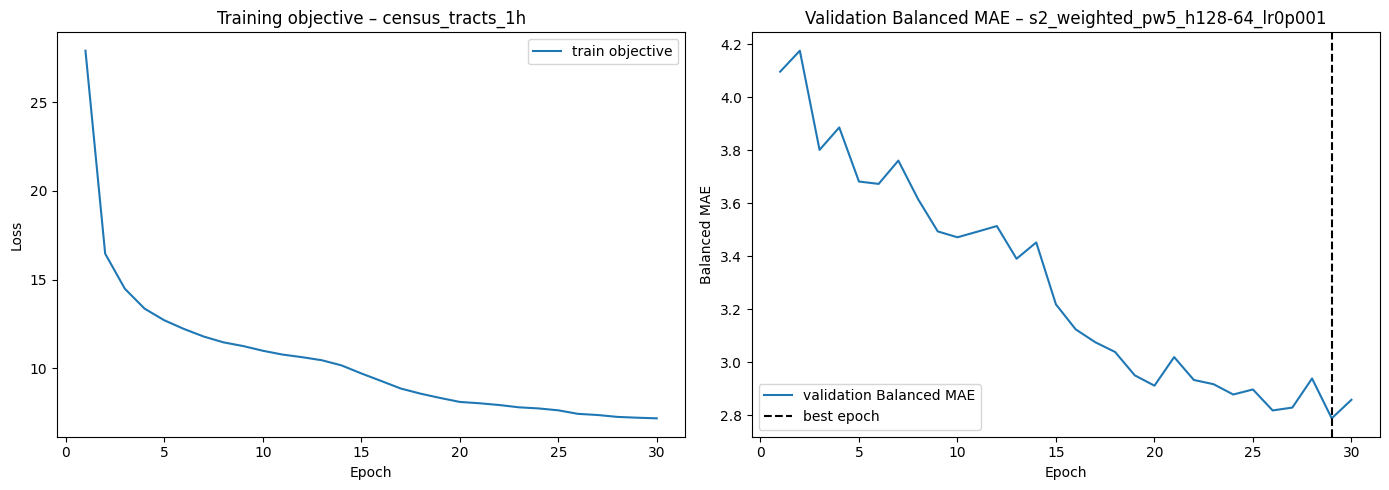

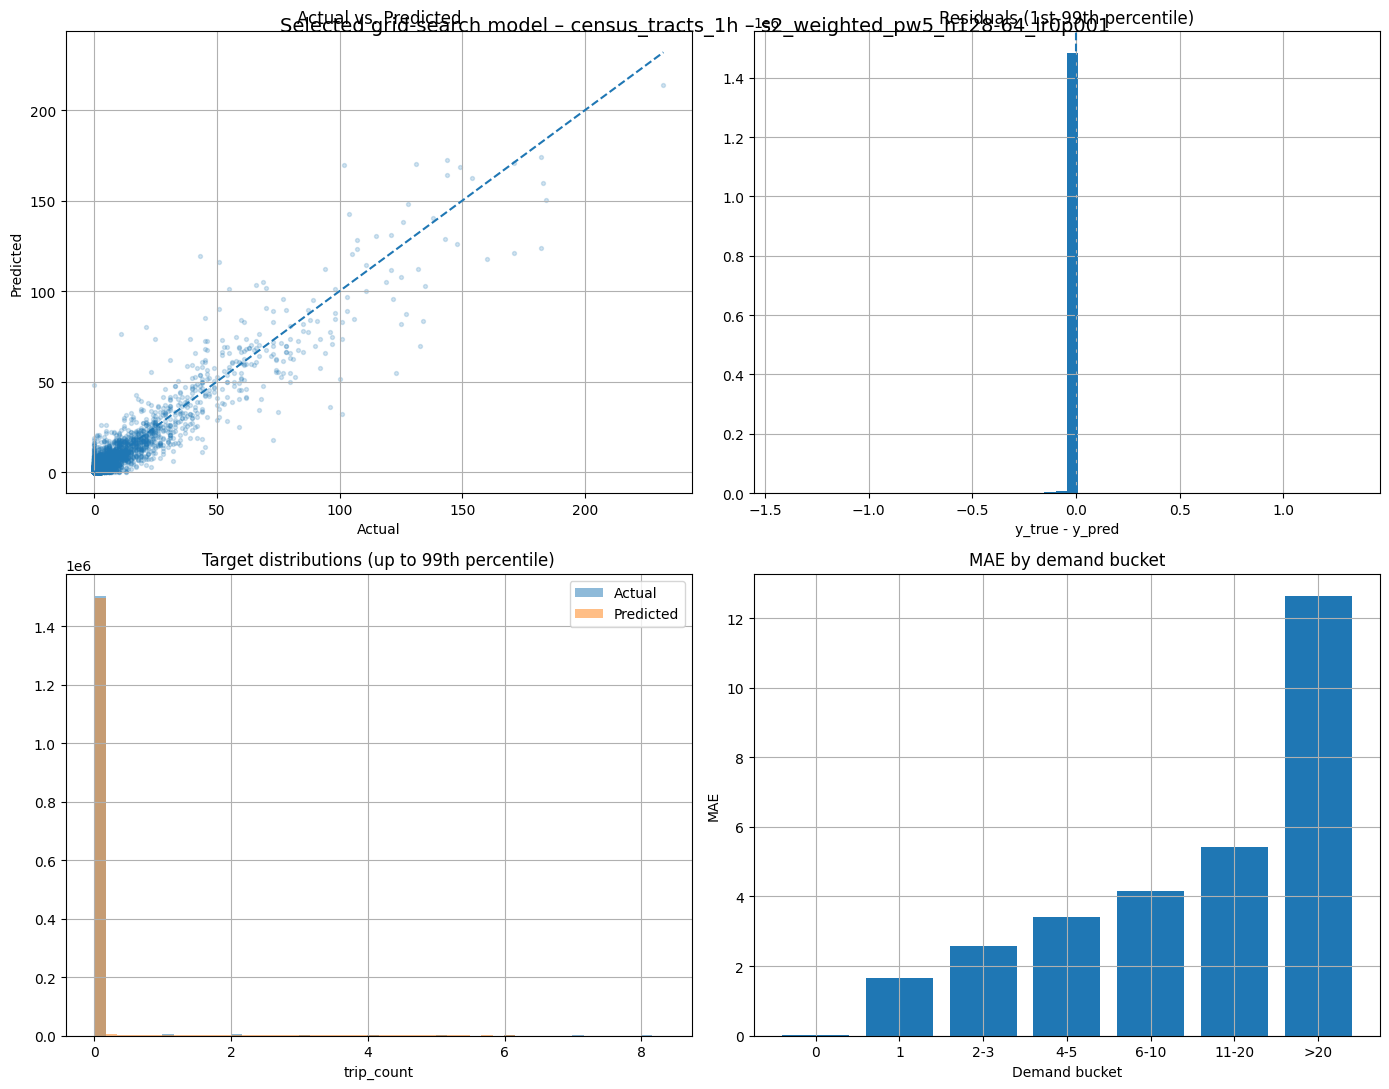

shape: (7, 5)
┌───────────────┬─────────┬───────────┬────────────┬──────────────┐
│ demand_bucket ┆ n_rows  ┆ mae       ┆ avg_y_true ┆ bucket_order │
│ ---           ┆ ---     ┆ ---       ┆ ---        ┆ ---          │
│ str           ┆ u32     ┆ f32       ┆ f32        ┆ i64          │
╞═══════════════╪═════════╪═══════════╪════════════╪══════════════╡
│ 0             ┆ 1504607 ┆ 0.018835  ┆ 0.0        ┆ 0            │
│ 1             ┆ 3986    ┆ 1.664046  ┆ 1.0        ┆ 1            │
│ 2-3           ┆ 7571    ┆ 2.577539  ┆ 2.439572   ┆ 2            │
│ 4-5           ┆ 3577    ┆ 3.412293  ┆ 4.466592   ┆ 3            │
│ 6-10          ┆ 5257    ┆ 4.15174   ┆ 7.749287   ┆ 4            │
│ 11-20         ┆ 5642    ┆ 5.410335  ┆ 14.88302   ┆ 5            │
│ >20           ┆ 7616    ┆ 12.640498 ┆ 52.50893   ┆ 6            │
└───────────────┴─────────┴───────────┴────────────┴──────────────┘


In [12]:
for model_tag, result in best_results.items():
    history = result["history"]
    figure, axes = plt.subplots(1, 2, figsize=(14, 5))
    axes[0].plot(history["epoch"], history["train_loss"], label="train objective")
    axes[0].set(title=f"Training objective – {model_tag}", xlabel="Epoch", ylabel="Loss")
    axes[0].legend()
    axes[1].plot(
        history["epoch"], history["val_balanced_mae"], label="validation Balanced MAE"
    )
    axes[1].axvline(result["row"]["best_epoch"], color="black", linestyle="--", label="best epoch")
    axes[1].set(
        title=f"Validation Balanced MAE – {result['row']['trial_tag']}",
        xlabel="Epoch", ylabel="Balanced MAE",
    )
    axes[1].legend()
    figure.tight_layout()
    plt.show()

    diagnostic_figure, bucket_metrics = plot_regression_diagnostics(result["predictions"])
    diagnostic_figure.suptitle(
        f"Selected grid-search model – {model_tag} – {result['row']['trial_tag']}",
        fontsize=14,
    )
    plt.show()
    print(bucket_metrics)